In [3]:
import pathlib
import numpy as np

local = pathlib.Path.cwd()
mlmodel = None
target = np.array([392, 518])

def mlpackage():
    global Image
    from PIL import Image
    from pillow_heif import register_heif_opener
    register_heif_opener()

    import coremltools as ct
    return ct.models.MLModel('DepthAnythingV2SmallF16.mlpackage')

def fs(pth, npy = None):
    global mlmodel
    if type(npy) is str:
        npy = pathlib.Path(npy)
    if npy is not None and npy.exists():
        return np.load(npy)
    if mlmodel is None:
        mlmodel = mlpackage()
    im = Image.open(pth)
    size = np.array(im.size)
    scaled = np.int32(np.max(target / size) * size)
    im_s = im.resize(scaled)
    origin = (scaled - target[::-1]) // 2
    im_t = im_s.crop(np.concat((origin, origin + target[::-1])))
    out = np.array(mlmodel.predict({"image": im_t})['depth'])
    if npy is not None:
        np.save(npy, out)
    return out

im4 = fs(local / "IMG_0004.HEIC", local / "out4.npy")
im5 = fs(local / "IMG_0005.HEIC", local / "out5.npy")

In [4]:
import matplotlib.pyplot as plt

In [41]:
from functools import cached_property
import sympy as sy

class Sphere:
    t0, t1 = target // 2
    offset = sy.Rational(1, 10)
    def __init__(self, r=np.min(target) // 5):
        self.r = r
        self.a, self.b = self.dim = sy.symbols('a b')

    @cached_property
    def rescale(self):
        return sy.Rational(4, 5 * self.r)

    @cached_property
    def im(self):
        out = np.zeros(target)
        c1, c0 = np.meshgrid(*map(np.arange, target[::-1]))
        d2 = (self.t0 - c0) ** 2 + (self.t1 - c1) ** 2
        out[d2 < self.r ** 2] = np.sqrt(self.r ** 2 - d2[d2 < self.r ** 2])
        out *= float(self.rescale)
        out[d2 < self.r ** 2] += float(self.offset)
        return out

    def sym(self):
        return self.offset + self.rescale * sy.sqrt(
                self.r ** 2 - (self.t0 - self.a) ** 2 - (self.t1 - self.b) ** 2)

    def grad(self):
        expr = self.sym()
        return sy.Matrix([[sy.diff(expr, self.a)], [sy.diff(expr, self.b)]])

    def hessian(self):
        expr = self.grad()
        return sy.Matrix.hstack(sy.diff(expr, self.a), sy.diff(expr, self.b))

    def eigenvalues(self):
        expr = self.hessian()
        tr = expr.trace()
        center = tr / 2
        radius = sy.sqrt(tr ** 2 / 4 - expr.det())
        return sy.Matrix([[center - radius], [center + radius]])

    def sec2(self):
        para, perp = self.eigenvalues()
        return para / perp

    def adjusted(self):
        d0, d1 = d = self.grad()
        return (self.sec2() - 1) / (d0 ** 2 + d1 ** 2) * d

    def at(self, *args):
        return list(zip(self.dim, args))

    def subs(self, a, b):
        return self.adjusted().subs(self.at(a, b))

    @cached_property
    def approx(self):
        return adjust(self.im)

    def cmp(self, a, b):
        return [i[a, b] for i in self.approx], \
                self.subs(a, b).T.evalf().tolist()[0]

class Concave(Sphere):
    @cached_property
    def im(self):
        arr = super().im
        return np.where(arr < float(self.offset) / 2, arr, 1 - arr)

In [42]:
a, b, c, p, w = sy.symbols('a b c p w')
expr = c + sy.sqrt(p ** 2 - a ** 2 - b ** 2) / w

change = [(b, 0)]
f = expr.subs(change)
da = sy.simplify(sy.diff(expr, a).subs(change))
da2 = sy.simplify(sy.diff(expr, a, a).subs(change))
db2 = sy.simplify(sy.diff(expr, b, b).subs(change))

print(sy.simplify((da2 / db2 - 1) / da ** 2))

w**2


In [45]:
from scipy.ndimage import sobel
from typing import Literal

coord = np.stack(np.meshgrid(*map(np.arange, target[::-1]))[::-1], -1)
diag = np.sqrt(np.sum(target ** 2))

def grad(arr):
    return np.stack((sobel(arr, 0), sobel(arr, 1)), -1) / 8

def hessian(partials):
    return np.stack((grad(partials[..., 0]), grad(partials[..., 1])), -1)

def interpolate(continuous: np.ndarray[tuple[int, Literal[2]], np.dtype[np.float64]]):
    out = np.zeros(target)
    floored = np.int32(np.floor(continuous))
    remainder = continuous - floored
    for offset in np.array([[[0, 0]], [[0, 1]], [[1, 0]], [[1, 1]]]):
        filling = floored + offset
        overlap = 1 - offset + (2 * offset - 1) * remainder
        oob0 = np.logical_and(filling[..., 0] >= 0, filling[..., 0] < target[0])
        oob1 = np.logical_and(filling[..., 1] >= 0, filling[..., 1] < target[1])
        valid = np.logical_and(oob0, oob1)
        np.add.at(
                out,
                (filling[valid][..., 0], filling[valid][..., 1]),
                overlap[valid][..., 0] * overlap[valid][..., 1])
    return out

def rotated(partials, second):
    norm = np.sqrt(np.sum(partials ** 2, -1, keepdims=True))
    basis0 = np.divide(
            partials, norm, out=np.zeros_like(partials), where=norm != 0)
    basis1 = basis0[..., ::-1] * np.array([[[-1, 1]]])
    basis = np.stack((basis0, basis1), -1)
    inv = basis * np.array([[[[1, -1], [-1, 1]]]])
    return inv @ second @ basis

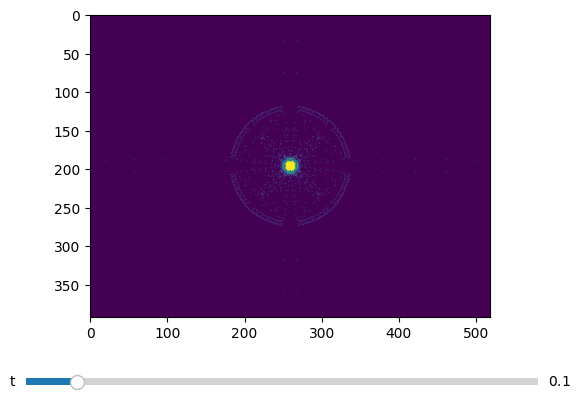

In [46]:
from functools import partial

def normals(partials, t):
    parametric = (coord + partials * t * diag).reshape([-1, 2])
    return interpolate(parametric)

def casts(im, slopes, depth):
    delta = im - depth
    intersection = coord + delta[..., None] * slopes
    return interpolate(intersection[delta > 0].reshape([-1, 2]))

def slide(f, **kw):
    frame = f(kw["valinit"] if "valinit" in kw else 0)

    from matplotlib.widgets import Slider, Button
    fig, ax = plt.subplots()
    out = ax.imshow(frame, vmin=0, vmax=4)
    fig.subplots_adjust(bottom=0.25)

    axt = fig.add_axes([0.1, 0.1, 0.8, 0.03])
    slider = Slider(ax=axt, label='t', **kw)
    def update(val):
        nonlocal frame
        frame = f(slider.val)
        out.set_data(frame)
        fig.canvas.draw_idle()
    slider.on_changed(update)

    plt.show()

def slide0(arr, slopes=None):
    slopes = grad(arr) if slopes is None else slopes
    return slide(partial(normals, slopes), valmin=0, valmax=8, valinit=0)

def adjust(arr):
    partials = grad(arr)
    second = hessian(partials)
    eigval, eigvec = np.linalg.eigh(second)
    # λ[0] = ∂∥∂∥ <= ∂⟂∂⟂ = λ[1]
    para, perp = np.min(eigval, -1), np.max(eigval, -1)
    # perp < 0 <-> negative definite <-> convex out-of-the-page/screen
    # the (first) eigenvectors should form a good basis for the gradient
    sec2 = np.divide(para, perp, out=np.ones_like(arr), where=perp != 0)
    # sec ** 2 - 1 = tan ** 2
    coef = (sec2 - 1) / np.sum(partials ** 2, -1)
    return partials * coef[..., None]

def slide1(arr, slopes=None, **kw):
    slopes = adjust(arr) if slopes is None else slopes
    defaults = { "valmin": 0, "valmax": 1, "valinit": 0.1 }
    return slide(partial(casts, arr, slopes), **{**defaults, **kw})

# https://www.desmos.com/c/h0pkuzhfzh
# https://www.desmos.com/3d/9ijh5b7ok9
# m = ∂∥∂∥ / (∂⟂∂⟂)^3 * ∂∥ wrt gradient
# https://www.desmos.com/3d/pt8citup10

def tmp6(arr=im5):
    partials = grad(arr)
    second = hessian(partials)
    out = rotated(partials, second)
    concave_down = np.logical_and(np.linalg.det(out) > 0, out[..., 0, 0] < 0)
    sec2 = np.divide(
            out[..., 0, 0], out[..., 1, 1],
            out=2 * np.ones_like(arr), where=concave_down)
    norm = np.sum(partials ** 2, -1)
    coef = np.divide(sec2 - 1, norm, out=np.ones_like(norm), where=norm != 0)
    slopes = partials * coef[..., None]
    slide1(arr, slopes)

if __name__ == "__main__":
    tmp6(Sphere().im)